In [1]:
import pandas as pd
import plotly.express as px
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [2]:
sns.set_theme(style='whitegrid', font_scale=1.0)
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'

RED = '#C00000'
DARK = '#111827'
GRAY = '#6B7280'
PALETTE = [RED, '#374151', '#9CA3AF', '#F97316', '#2563EB', '#16A34A', '#7C3AED', '#DB2777']

In [3]:
pd.set_option('display.max_columns', 30)
df = pd.read_csv(r'D:\TECHTRECK\retail_visualization_dataset.csv', cache_dates=False)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2612 entries, 0 to 2611
Data columns (total 26 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   order_id            2612 non-null   object 
 1   order_date          2612 non-null   object 
 2   year                2612 non-null   int64  
 3   month               2612 non-null   object 
 4   region              2612 non-null   object 
 5   city                2577 non-null   object 
 6   channel             2612 non-null   object 
 7   customer_segment    2612 non-null   object 
 8   acquisition_source  2612 non-null   object 
 9   marketing_campaign  2612 non-null   object 
 10  product_category    2612 non-null   object 
 11  product             2612 non-null   object 
 12  brand               2612 non-null   object 
 13  quantity            2612 non-null   int64  
 14  unit_price          2612 non-null   float64
 15  discount_pct        2612 non-null   float64
 16  shippi

In [5]:
df.head()

,order_id,order_date,year,month,region,city,channel,customer_segment,acquisition_source,marketing_campaign,product_category,product,brand,quantity,unit_price,discount_pct,shipping_cost,gross_sales,revenue,cost,profit,profit_margin,returned,payment_method,rating,delivery_days
0,ORD-100001,2025-04-25,2025,Apr,Greater Cairo,New Cairo,Mobile App,Consumer,Facebook Ads,Summer Launch,Electronics,Laptop Pro,Nova,1,31376.83,0.02,144.56,31376.83,30749.29,18198.56,12406.17,0.4035,No,Cash,2.9,1
1,ORD-100002,2026-03-09,2026,Mar,Greater Cairo,Giza,Mobile App,Consumer,Instagram Ads,Summer Launch,Electronics,Wireless Earbuds,DailyGood,1,1912.39,0.05,115.80,1912.39,1816.77,1051.81,649.16,0.3573,No,Wallet,3.0,1
2,ORD-100003,2025-07-16,2025,Jul,Alexandria,Alexandria,Mobile App,Consumer,Referral,Summer Launch,Home & Furniture,LED Desk Lamp,DailyGood,2,764.12,0.14,137.23,1528.24,1314.29,809.97,367.09,0.2793,No,Cash,3.1,3
3,ORD-100004,2025-06-17,2025,Jun,Delta,Tanta,Marketplace,Student,Facebook Ads,Ramadan Deals,Grocery,Dates Box,TechTrail,2,340.52,0.17,72.84,681.04,565.26,231.55,260.87,0.4615,No,Installments,4.6,1
4,ORD-100005,2026-02-10,2026,Feb,Canal,Suez,Marketplace,Corporate,Instagram Ads,Summer Launch,Fashion,Summer Dress,GlowUp,3,875.79,0.10,44.55,2627.37,2364.63,1182.32,1137.76,0.4812,Yes,Bank Transfer,3.2,1


In [6]:
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

In [7]:
df.columns

Index(['order_id', 'order_date', 'year', 'month', 'region', 'city', 'channel',
       'customer_segment', 'acquisition_source', 'marketing_campaign',
       'product_category', 'product', 'brand', 'quantity', 'unit_price',
       'discount_pct', 'shipping_cost', 'gross_sales', 'revenue', 'cost',
       'profit', 'profit_margin', 'returned', 'payment_method', 'rating',
       'delivery_days'],
      dtype='object')

In [10]:
category_revenue = df.groupby('product_category')['revenue'].sum().sort_values(ascending=False)
top_products = df.groupby('product')['revenue'].sum().sort_values(ascending=False).head(10)

In [11]:
most_channel_used = df['channel'].value_counts()
most_channel_used

channel
Online Store       785
Mobile App         628
Retail Branch      577
Marketplace        420
Social Commerce    202
Name: count, dtype: int64

<Axes: title={'center': 'Most Used Channel'}, xlabel='channel'>

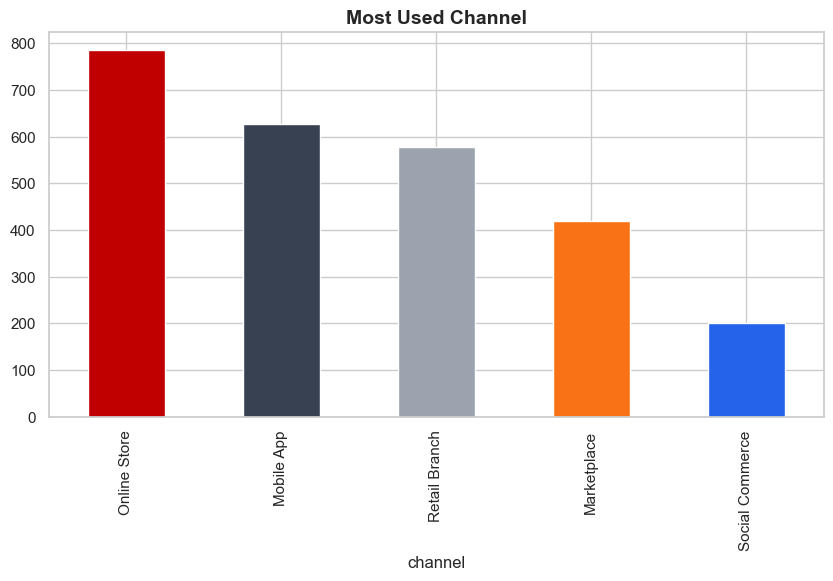

In [ ]:
most_channel_used.plot(kind='bar',title='Most Used Channel', color=PALETTE) ## static visual 

In [14]:
fig = px.bar(most_channel_used, x=most_channel_used.index, y=most_channel_used.values, title='Most Used Channel', color=most_channel_used.index, color_discrete_sequence=PALETTE) ## interactive visual
fig.update_layout(xaxis_title='Channel', yaxis_title='Count')

In [15]:
fig_of_category = px.bar(category_revenue, x=category_revenue.index, y=category_revenue.values, title='Most Used Region', color=category_revenue.index, color_discrete_sequence=PALETTE)
fig_of_category.update_layout(xaxis_title='Product Category', yaxis_title='Revenue')


In [16]:
px.pie(top_products, names=top_products.index, values=top_products.values, title='Top 10 Products by Revenue', color_discrete_sequence=PALETTE)

In [17]:
every_region_revenue = df.groupby('region')['revenue'].sum().sort_values()


In [32]:
fig_rev = px.bar(every_region_revenue, x=every_region_revenue.index, y=every_region_revenue.values, title='Revenue by Region')
fig_rev

In [39]:
px.scatter(df,x='cost',y='revenue')

In [40]:
df.head()

,order_id,order_date,year,month,region,city,channel,customer_segment,acquisition_source,marketing_campaign,product_category,product,brand,quantity,unit_price,discount_pct,shipping_cost,gross_sales,revenue,cost,profit,profit_margin,returned,payment_method,rating,delivery_days
0,ORD-100001,2025-04-25,2025,Apr,Greater Cairo,New Cairo,Mobile App,Consumer,Facebook Ads,Summer Launch,Electronics,Laptop Pro,Nova,1,31376.83,0.02,144.56,31376.83,30749.29,18198.56,12406.17,0.4035,No,Cash,2.9,1
1,ORD-100002,2026-03-09,2026,Mar,Greater Cairo,Giza,Mobile App,Consumer,Instagram Ads,Summer Launch,Electronics,Wireless Earbuds,DailyGood,1,1912.39,0.05,115.80,1912.39,1816.77,1051.81,649.16,0.3573,No,Wallet,3.0,1
2,ORD-100003,2025-07-16,2025,Jul,Alexandria,Alexandria,Mobile App,Consumer,Referral,Summer Launch,Home & Furniture,LED Desk Lamp,DailyGood,2,764.12,0.14,137.23,1528.24,1314.29,809.97,367.09,0.2793,No,Cash,3.1,3
3,ORD-100004,2025-06-17,2025,Jun,Delta,Tanta,Marketplace,Student,Facebook Ads,Ramadan Deals,Grocery,Dates Box,TechTrail,2,340.52,0.17,72.84,681.04,565.26,231.55,260.87,0.4615,No,Installments,4.6,1
4,ORD-100005,2026-02-10,2026,Feb,Canal,Suez,Marketplace,Corporate,Instagram Ads,Summer Launch,Fashion,Summer Dress,GlowUp,3,875.79,0.10,44.55,2627.37,2364.63,1182.32,1137.76,0.4812,Yes,Bank Transfer,3.2,1


In [ ]:
## most date have sales
date_revenue = df.groupby('order_date')['revenue'].sum().sort_values()
px.scatter(date_revenue, x=date_revenue.index, y=date_revenue.values, title='Revenue by Date')

order_date
2025-10-20       303.70
2025-08-27       379.89
2026-01-23       816.98
2025-06-05       859.14
2026-04-22       919.75
                ...    
2026-01-14     85264.48
2025-09-22     87818.66
2026-01-26     90272.99
2026-01-19    104089.24
2025-02-11    122044.84
Name: revenue, Length: 540, dtype: float64

In [46]:
returned_distribution = df['returned'].value_counts()
returned_distribution

returned
No     2477
Yes     115
N         6
yes       6
no        4
Y         4
Name: count, dtype: int64

In [49]:
df['returned'] = df['returned'].replace({'Y': 'Yes', 'N': 'No' , 'yes': 'Yes', 'no': 'No'})

In [50]:
returned_distribution = df['returned'].value_counts()
returned_distribution 

returned
No     2487
Yes     125
Name: count, dtype: int64

In [51]:
px.pie(returned_distribution, names=returned_distribution.index, values=returned_distribution.values, title='Returned Distribution', color_discrete_sequence=PALETTE)

## sea born


In [56]:
city_by_revenue = df.groupby('city')['revenue'].sum().sort_values().reset_index(name='total_revenue')

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13],
 [Text(0, 0, 'Luxor'),
  Text(1, 0, 'Assiut'),
  Text(2, 0, 'Aswan'),
  Text(3, 0, 'Port Said'),
  Text(4, 0, 'Suez'),
  Text(5, 0, 'Zagazig'),
  Text(6, 0, 'Ismailia'),
  Text(7, 0, 'Mansoura'),
  Text(8, 0, 'Tanta'),
  Text(9, 0, 'Cairo'),
  Text(10, 0, '6 October'),
  Text(11, 0, 'New Cairo'),
  Text(12, 0, 'Giza'),
  Text(13, 0, 'Alexandria')])

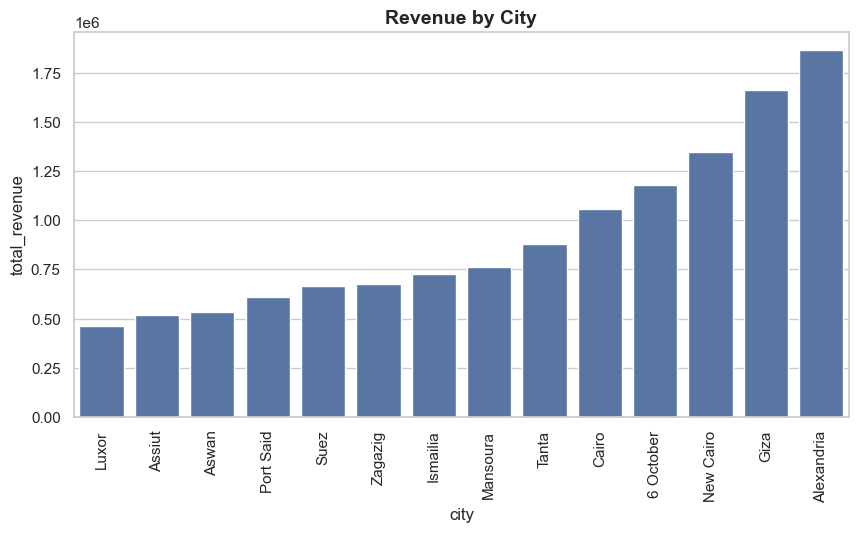

In [64]:
sns.barplot(data=city_by_revenue, x='city', y='total_revenue')
plt.title('Revenue by City')
plt.xticks(rotation=90)

In [73]:
year_revenue = df.groupby('year')['revenue'].sum().sort_values()
year_revenue = year_revenue.to_frame(name='revenue').reset_index()

([0, 1], [Text(0, 0, '2025'), Text(1, 0, '2026')])

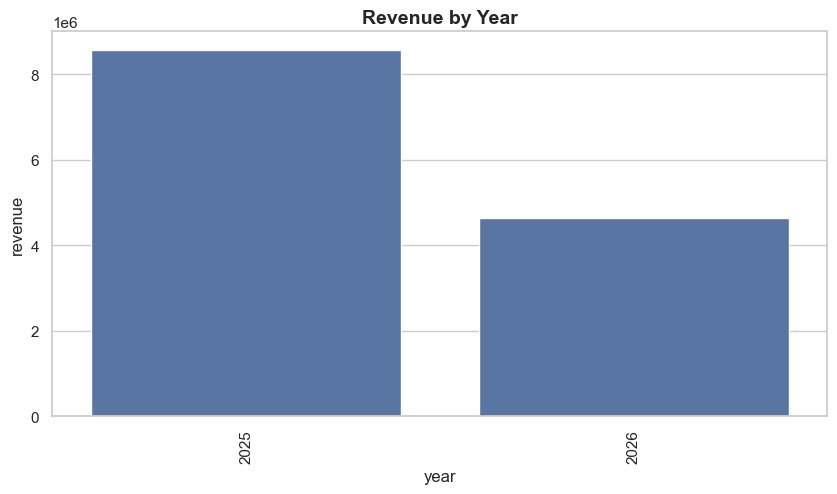

In [74]:
sns.barplot(data=year_revenue, x='year', y='revenue')
plt.title('Revenue by Year')
plt.xticks(rotation=90)

<Axes: xlabel='gross_sales', ylabel='Count'>

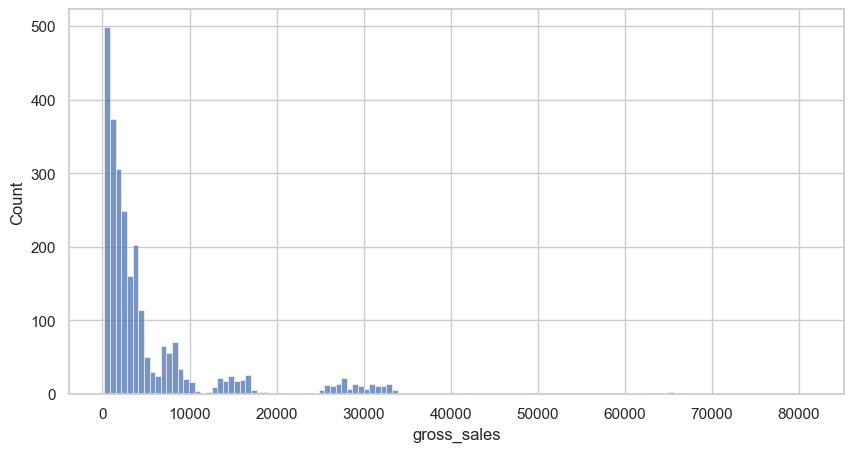

In [75]:
sns.histplot(df['gross_sales'])

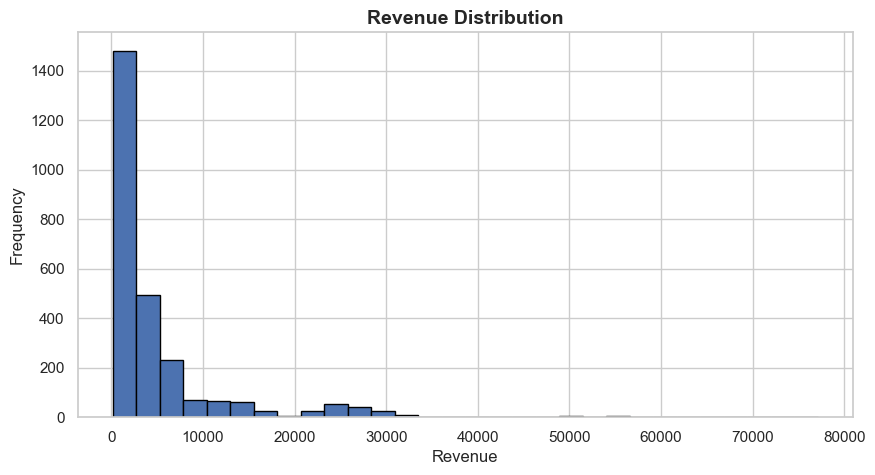

In [78]:
plt.hist(df['revenue'], bins=30, edgecolor='black')
plt.title('Revenue Distribution')
plt.xlabel('Revenue')
plt.ylabel('Frequency')
plt.show()

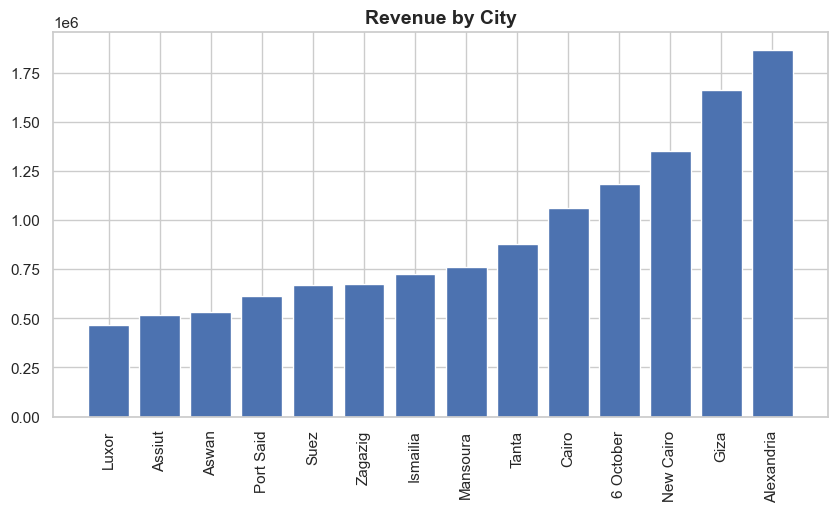

In [79]:
plt.bar(city_by_revenue['city'], city_by_revenue['total_revenue'])
plt.title('Revenue by City')
plt.xticks(rotation=90)
plt.show()

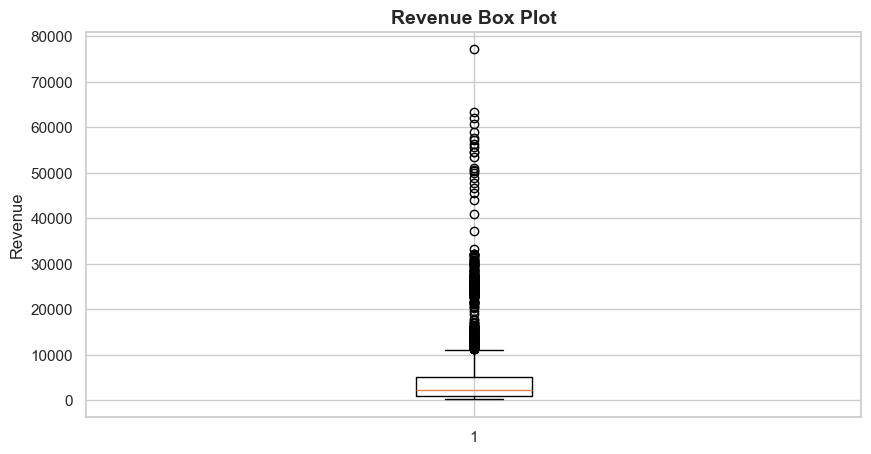

In [80]:
plt.boxplot(df['revenue'])
plt.title('Revenue Box Plot')
plt.ylabel('Revenue')
plt.show()